## CSV

In [ ]:
import requests

url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/addresses.csv'

def download_file(url, file_name):
    response = requests.get(url)

    if response.status_code == 200:

        with open(file_name, "wb") as f:
            f.write(response.content)
        print(f"Đã tải xong: {file_name}")
    else:
        print("Lỗi tải file!")

download_file(url, "du_lieu.csv")

Đã tải xong: du_lieu.csv


In [ ]:
import pandas as pd
df = pd.read_csv('du_lieu.csv',header = None) #phai co header
df.columns = ['First name','Last name','Location','City','State','Area code']
df

,First name,Last name,Location,City,State,Area code
0,John,Doe,120 jefferson st.,Riverside,NJ,8075
1,Jack,McGinnis,220 hobo Av.,Phila,PA,9119
2,"John ""Da Man""",Repici,120 Jefferson St.,Riverside,NJ,8075
3,Stephen,Tyler,"7452 Terrace ""At the Plaza"" road",SomeTown,SD,91234
4,NaN,Blankman,NaN,SomeTown,SD,298
5,"Joan ""the bone"", Anne",Jet,"9th, at Terrace plc",Desert City,CO,123


In [ ]:
df.loc[[1,3,5],'City'] #no khac 1:5 (1 2 3 4 5) ---- no chi lay 1 3 5 thoi

1          Phila
3       SomeTown
5    Desert City
Name: City, dtype: str

In [16]:
import numpy as np
df=pd.DataFrame(np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]]), columns = ['a', 'b', 'c'])
df

,a,b,c
0,1,2,3
1,4,5,6
2,7,8,9


In [20]:
df = df.transform(lambda x : x + 10)
df

,a,b,c
0,21,22,23
1,24,25,26
2,27,28,29


In [21]:
result = df.transform(['sqrt']) #có ngoặc vuông để thêm tên 'sqrt' vào cột
#result = df.transform(['sqrt','exp'])  #ap dung nhiu ham 1 luc
#result = df.transform(np.sqrt)
result

,a,b,c
,sqrt,sqrt,sqrt
0,4.582576,4.690416,4.795832
1,4.898979,5.000000,5.099020
2,5.196152,5.291503,5.385165


## JSON

In [23]:
import json
person = {
    'first_name' : 'Mark',
    'last_name' : 'abc',
    'age' : 27,
    'address': {
        "streetAddress": "21 2nd Street",
        "city": "New York",
        "state": "NY",
        "postalCode": "10021-3100"
    }
}

In [ ]:
'''
json.dump --> converting a dictionary to a JSON object
Syntax: json.dump(dict, file_pointer)
    dictionary - name of the dictionary which should be converted to JSON object.
    ile pointer - pointer of the file opened in write or append mode.'''

with open('person.json','w') as f:
    json.dump(person,f)


In [35]:
#tuong tu load, thì dumps sẽ chuyển thành string
json_object = json.dumps(person, indent = 1)
with open('sample.json','a') as f:
    f.write(json_object)
print(json_object)
type(json_object) #str

{
 "first_name": "Mark",
 "last_name": "abc",
 "age": 27,
 "address": {
  "streetAddress": "21 2nd Street",
  "city": "New York",
  "state": "NY",
  "postalCode": "10021-3100"
 }
}


str

# load: chuyen Json -> Dict
# dump: chuyen Dict -> Json

In [ ]:
with open('sample.json','r') as f:
    new_json = json.load(f)

print(new_json)
print(type(new_json))
pd.DataFrame(new_json)

{'first_name': 'Mark', 'last_name': 'abc', 'age': 27, 'address': {'streetAddress': '21 2nd Street', 'city': 'New York', 'state': 'NY', 'postalCode': '10021-3100'}}
<class 'dict'>


,first_name,last_name,age,address
streetAddress,Mark,abc,27,21 2nd Street
city,Mark,abc,27,New York
state,Mark,abc,27,NY
postalCode,Mark,abc,27,10021-3100


## XLSX

In [46]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/file_example_XLSX_10.xlsx"

def download_file_xlsx(url, filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open(filename, 'wb') as f:
            f.write(response.content)
            print("Done!")
    else: print("Error!")

download_file_xlsx(url,'file.xlsx')
df = pd.read_excel('file.xlsx')
df

Done!


,0,First Name,Last Name,Gender,Country,Age,Date,Id
0,1,Dulce,Abril,Female,United States,32,15/10/2017,1562
1,2,Mara,Hashimoto,Female,Great Britain,25,16/08/2016,1582
2,3,Philip,Gent,Male,France,36,21/05/2015,2587
3,4,Kathleen,Hanner,Female,United States,25,15/10/2017,3549
4,5,Nereida,Magwood,Female,United States,58,16/08/2016,2468
5,6,Gaston,Brumm,Male,United States,24,21/05/2015,2554
6,7,Etta,Hurn,Female,Great Britain,56,15/10/2017,3598
7,8,Earlean,Melgar,Female,United States,27,16/08/2016,2456
8,9,Vincenza,Weiland,Female,United States,40,21/05/2015,6548


## XML

In [54]:
import xml.etree.ElementTree as ET

# create the file structure
employee = ET.Element('employee') #root
details = ET.SubElement(employee, 'details') #sau trở đi là con của root
first = ET.SubElement(details, 'firstname')
second = ET.SubElement(details, 'lastname')
third = ET.SubElement(details, 'age')
first.text = 'Shiv' #nội dung của thẻ
second.text = 'Mishra'
third.text = '23'

# create a new XML file with the results
mydata1 = ET.ElementTree(employee) #
# myfile = open("items2.xml", "wb")
# myfile.write(mydata)
with open("new_sample.xml", "wb") as files:
    mydata1.write(files)


In [55]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/Sample-employee-XML-file.xml"
def download_fxml(url, file_name):
    response = requests.get(url)
    if response.status_code == 200:
        with open(file_name, 'wb') as f:
            f.write(response.content)
            print("Done")
    else: print("Error")

download_fxml(url,'employee.xml')

Done


In [87]:
import xml.etree.ElementTree as etree
tree = etree.parse('employee.xml') #lấy toàn bộ cây
root = tree.getroot() #lấy phần chính (root - cha)
columns = ["firstname", "lastname", "title", "division", "building", "room"] #tên cột
df = pd.DataFrame(columns = columns) #tạo 1 df rỗng chỉ chứa tên cột
for node in root:
    firstname = node.find("firstname").text
    lastname = node.find('lastname').text
    title = node.find('title').text
    division = node.find('division').text
    building = node.find('building').text
    room = node.find('room').text

    row_df = pd.DataFrame([[firstname, lastname, title, division, building, room]], columns = columns)
    '''
    #pd.concat: cơ chế khớp nhãn, nếu ko khớp thì sẽ tạo thêm n cột của dataframe thứ 2 (df) nên hàm columns = sẽ tạo
    cho 2 dataframe có chung tên cột

    #ignore_index: khi dòng row_df = pd.DataFrame([[...]]) tạo 1 dòng và chỉ số hàng của nó = 0, nên khi loop thì chỉ
    tạo thêm nhiều hàng có chỉ số 0. và hàm pd.concat chỉ ghép vào mà mặc kệ chỉ số, nên hàm ignore_index để làm index
    theo thứ tự
    '''
    df = pd.concat([row_df,df], ignore_index=True)
df



,firstname,lastname,title,division,building,room
0,Deep,Parekh,Designer,Computer,305,14
1,Rahil,Khan,Tester,Computer,304,10
2,Yuh,Datta,developer,Computer,303,02
3,Shiv,Mishra,Engineer,Computer,301,11


## SAVE

In [99]:
#để chuyển dataFrame thành 1 file thì dùng to_csv (to_json, to_excel, ...)
df.to_csv('employee_created.csv', index = False)

## READ XML khác etree

In [97]:
pd.read_xml('employee.xml', xpath = '/employees/details')

,firstname,lastname,title,division,building,room
0,Shiv,Mishra,Engineer,Computer,301,11
1,Yuh,Datta,developer,Computer,303,2
2,Rahil,Khan,Tester,Computer,304,10
3,Deep,Parekh,Designer,Computer,305,14


## Read Image file

In [104]:
from PIL import Image
url = "https://hips.hearstapps.com/hmg-prod.s3.amazonaws.com/images/dog-puppy-on-garden-royalty-free-image-1586966191.jpg"
def download_image(url, filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open(filename, 'wb') as f:
            f.write(response.content)
            print("Done")
    else: print("Error")
download_image(url, 'dog.png')

Done


In [105]:
png = Image.open('dog.png','r')
png.show()

### DATA ANALYST

In [107]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/diabetes.csv"

def download_benh(url,filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open(filename, 'wb') as f:
            f.write(response.content)
            print("Done")
    else: print("Error")

download_benh(url,'diabetes.csv')

Done


In [108]:
df = pd.read_csv('diabetes.csv')
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.shape #(hang,cot)

(768, 9)

# Statistical

In [110]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [117]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## missing values

In [127]:
miss_data = df.isnull() #true la thieu, false la ko thieu
miss_data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
763,False,False,False,False,False,False,False,False,False
764,False,False,False,False,False,False,False,False,False
765,False,False,False,False,False,False,False,False,False
766,False,False,False,False,False,False,False,False,False


In [ ]:
'''
- .columns : trả về 1 danh sách tên các cột
- .values : chuyển danh sách đó về dạng array
- .tolist() : chuyển mảng đó về dạng list
- .value_counts : gom các giá trị giống nhau thành 1 nhóm --- và đếm số lần xuất hiện
'''
for column in miss_data.columns.values.tolist():
    # print(column)
    print(miss_data[column].value_counts())  #miss_data[column] - lấy cột
    print() 
# => ko có true

Pregnancies
False    768
Name: count, dtype: int64

Glucose
False    768
Name: count, dtype: int64

BloodPressure
False    768
Name: count, dtype: int64

SkinThickness
False    768
Name: count, dtype: int64

Insulin
False    768
Name: count, dtype: int64

BMI
False    768
Name: count, dtype: int64

DiabetesPedigreeFunction
False    768
Name: count, dtype: int64

Age
False    768
Name: count, dtype: int64

Outcome
False    768
Name: count, dtype: int64



In [ ]:
'''
.dtypes - to check the data type

df['col'] = df['col'].astype() - to change the data type
df = df.astype({'col1': 'int', 'col2': 'float'})

df.rename(columns = {'GDP (Million USD)':'GDP (Billion USD)'},inplace=True) ---- doi ten 1 cot
'''
df.dtypes #co the thay cac cot deu dung type

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

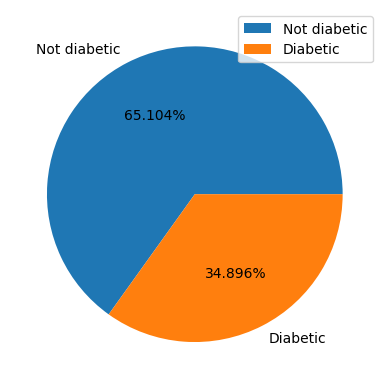

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = 'Not diabetic','Diabetic'
plt.pie(df['Outcome'].value_counts(),labels = labels, autopct='%.3f%%')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
df = pd.DataFrame(columns=['hien','ly'])
a = {'hien':['trung'],'ly':['nghia']}
d1 = pd.DataFrame(a)
df = pd.concat([d1,d1],ignore_index= True)
d1


,hien,ly
0,trung,nghia
